# RQ2a — Effect of Number of Committed Peers
Sweeps n_com ∈ {0, 2, 4, 6} with authority absent. Shows how conformity scales with peer commitment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path("../results_todos/rq2a")

RQ2A_CONDITIONS = ["rq2a_commit0", "rq2a_commit2", "rq2a_commit4", "rq2a_commit6"]
CONDITION_LABELS = {
    "rq2a_commit0": "0 committed",
    "rq2a_commit2": "2 committed",
    "rq2a_commit4": "4 committed",
    "rq2a_commit6": "6 committed",
}
N_COM = [0, 2, 4, 6]

def dataset_of(csv_path):
    """Classify a metrics CSV as in-distribution (primevul) or out-of-distribution (ood_benchmark)."""
    name = csv_path.name
    if "ood_benchmark" in name:
        return "ood"
    if "primevul" in name:
        return "id"
    return None

id_dfs, ood_dfs = [], []
for csv_path in sorted(RESULTS_DIR.rglob("*.metrics.csv")):
    if "_all_seeds" in csv_path.name:
        continue
    parts = csv_path.parts
    if not any(p.startswith("seed_") for p in parts):
        continue
    dataset = dataset_of(csv_path)
    if dataset is None:
        continue
    df = pd.read_csv(csv_path)
    df = df[df["condition"].isin(RQ2A_CONDITIONS + ["ALL"])]
    if df.empty:
        continue
    (id_dfs if dataset == "id" else ood_dfs).append(df)

all_per_seed = pd.concat(id_dfs, ignore_index=True) if id_dfs else pd.DataFrame()
combined = all_per_seed.groupby(["model", "condition"]).mean(numeric_only=True).reset_index()

all_per_seed_ood = pd.concat(ood_dfs, ignore_index=True) if ood_dfs else pd.DataFrame()
combined_ood = all_per_seed_ood.groupby(["model", "condition"]).mean(numeric_only=True).reset_index()

MODELS = sorted(combined["model"].unique())
PALETTE = sns.color_palette("tab10", len(MODELS))
MODEL_COLORS = dict(zip(MODELS, PALETTE))

print(f"Models: {MODELS}")
print(f"In-distribution (primevul) conditions: {sorted(combined['condition'].unique())}")
print(f"Out-of-distribution (ood_benchmark) conditions: "
      f"{sorted(combined_ood['condition'].unique()) if not combined_ood.empty else 'no OOD data found'}")


Models: ['llama31_it', 'mistral_it', 'phi35_it', 'qwen25_it']
In-distribution (primevul) conditions: ['ALL', 'rq2a_commit0', 'rq2a_commit2', 'rq2a_commit4', 'rq2a_commit6']
Out-of-distribution (ood_benchmark) conditions: ['ALL', 'rq2a_commit0', 'rq2a_commit2', 'rq2a_commit4', 'rq2a_commit6']


## Per-model metrics tables

> **Note on baseline (acc_r1):** Fractional values in the `n` column reflect that Mistral had skipped rows (malformed JSON outputs) across seeds, so the average is non-integer. The baseline acc_r1 for Mistral (~45%) may differ from RQ1 (~56%) if a different random sample of 500 functions was used at generation time — verify both datasets were generated with the same `--seed` and `--input` file.

In [2]:
display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                "rev_pct", "harm_pct", "ben_pct", "mean_dC"]

for model in MODELS:
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin(RQ2A_CONDITIONS))].copy()
    present = [c for c in RQ2A_CONDITIONS if c in df_m["condition"].values]
    df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
    df_m = df_m.sort_values("condition")[display_cols].reset_index(drop=True)
    print(f"\n{'─'*60}\n  {model.upper()}\n{'─'*60}")
    display(df_m.style
        .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                 **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct","mean_dC"]}}, na_rep="N/A")
        .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
        .background_gradient(subset=["harm_pct"], cmap="Reds", vmin=0, vmax=100)
        .background_gradient(subset=["ben_pct"], cmap="Greens", vmin=0, vmax=100)
        .set_caption(model))



────────────────────────────────────────────────────────────
  LLAMA31_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,53.3,53.4,0.1,30.1,28.2,32.4,-1.5
1,rq2a_commit2,500,53.3,54.2,0.9,29.3,26.7,32.4,-0.9
2,rq2a_commit4,500,53.3,51.6,-1.7,28.3,28.2,28.5,-0.9
3,rq2a_commit6,500,53.3,51.8,-1.5,29.3,28.9,29.8,-0.8



────────────────────────────────────────────────────────────
  MISTRAL_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,499.33,55.9,55.5,-0.4,0.4,0.7,0.0,-0.2
1,rq2a_commit2,498.33,55.6,54.1,-1.6,3.2,4.3,1.8,-0.1
2,rq2a_commit4,498.33,56.0,55.4,-0.6,4.2,4.3,4.1,-0.0
3,rq2a_commit6,497.67,55.7,54.7,-1.0,2.2,2.9,1.4,0.2



────────────────────────────────────────────────────────────
  PHI35_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,50.6,50.6,0.0,0.0,0.0,0.0,0.0
1,rq2a_commit2,500,50.6,50.6,0.0,1.2,1.2,1.2,-0.0
2,rq2a_commit4,500,50.6,51.2,0.6,1.8,1.2,2.4,0.0
3,rq2a_commit6,500,50.6,50.6,0.0,1.6,1.6,1.6,0.0



────────────────────────────────────────────────────────────
  QWEN25_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,59.7,58.3,-1.3,21.1,18.8,24.5,0.4
1,rq2a_commit2,500,59.7,56.4,-3.3,33.1,30.5,37.0,0.8
2,rq2a_commit4,500,59.7,53.5,-6.1,30.9,31.1,30.7,0.8
3,rq2a_commit6,500,59.7,52.0,-7.7,36.5,37.0,35.7,0.9


## Δ Accuracy vs n_com (line plot per model)

> **Note:** `rq2a_commit6` is structurally identical to RQ1 `mixed_absent` (same peer prompt, same instances). Do not combine these two data sources in any joint analysis.

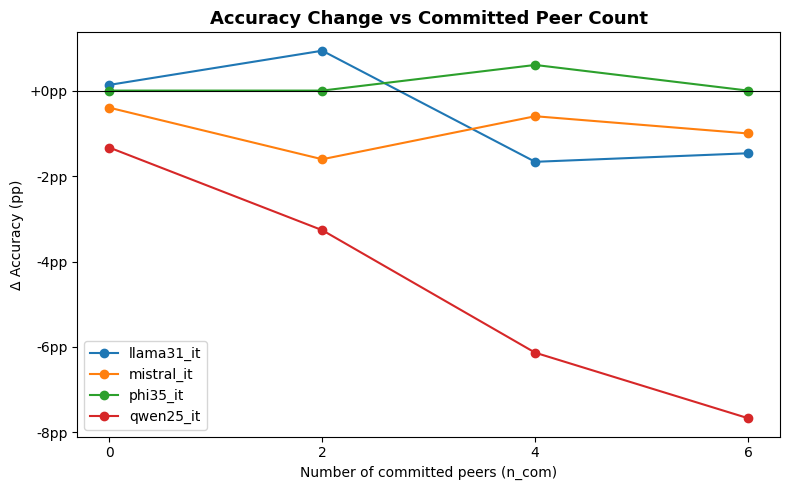

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for model in MODELS:
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin([f"rq2a_commit{n}" for n in N_COM]))].copy()
    df_m["n_com"] = df_m["condition"].str.extract(r"commit(\d+)").astype(int)
    df_m = df_m.sort_values("n_com")
    ax.plot(df_m["n_com"], df_m["delta_acc"], marker="o", label=model)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Number of committed peers (n_com)")
ax.set_ylabel("\u0394 Accuracy (pp)")
ax.set_title("Accuracy Change vs Committed Peer Count", fontsize=13, fontweight="bold")
ax.set_xticks(N_COM)
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rq2a_delta_acc_vs_ncom.png", dpi=150, bbox_inches="tight")
plt.show()


## Harmful % vs n_com

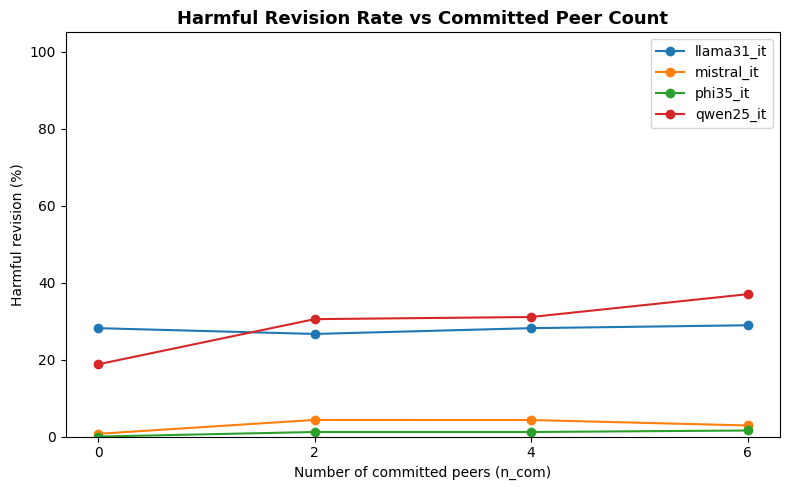

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for model in MODELS:
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin([f"rq2a_commit{n}" for n in N_COM]))].copy()
    df_m["n_com"] = df_m["condition"].str.extract(r"commit(\d+)").astype(int)
    df_m = df_m.sort_values("n_com")
    ax.plot(df_m["n_com"], df_m["harm_pct"], marker="o", label=model)

ax.set_xlabel("Number of committed peers (n_com)")
ax.set_ylabel("Harmful revision (%)")
ax.set_title("Harmful Revision Rate vs Committed Peer Count", fontsize=13, fontweight="bold")
ax.set_xticks(N_COM)
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rq2a_harmful_vs_ncom.png", dpi=150, bbox_inches="tight")
plt.show()


## Δ Accuracy heatmap — models × conditions

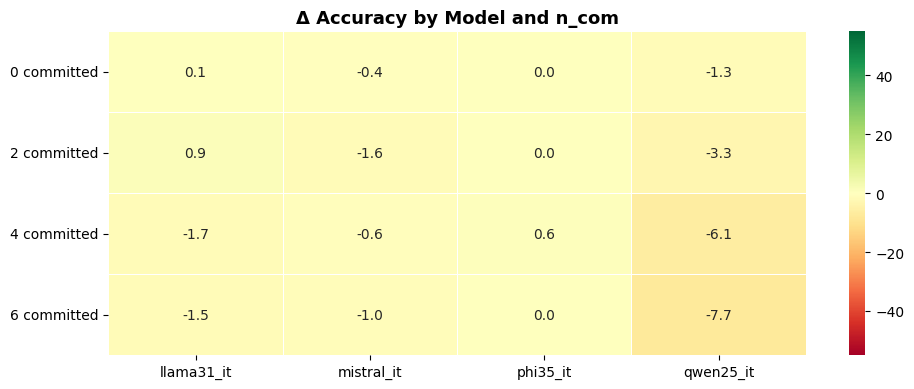

In [5]:
df_plot = combined[combined["condition"].isin([f"rq2a_commit{n}" for n in N_COM])]
pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
pivot = pivot.reindex([f"rq2a_commit{n}" for n in N_COM if f"rq2a_commit{n}" in pivot.index])
fig, ax = plt.subplots(figsize=(max(6, 2.5*len(MODELS)), 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("\u0394 Accuracy by Model and n_com", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels([CONDITION_LABELS.get(c, c) for c in pivot.index], rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rq2a_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# Out-of-Distribution (OOD) Results

Repeats the analysis above using the `ood_benchmark_rq2a` files instead of `primevul_rq2a`, to check whether the committed-peer-count effect generalizes beyond the in-distribution (ID) dataset.

## Per-model metrics tables — OOD

In [6]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                    "rev_pct", "harm_pct", "ben_pct", "mean_dC"]

    for model in MODELS:
        df_m = combined_ood[(combined_ood["model"] == model) & (combined_ood["condition"].isin(RQ2A_CONDITIONS))].copy()
        present = [c for c in RQ2A_CONDITIONS if c in df_m["condition"].values]
        df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
        df_m = df_m.sort_values("condition")[display_cols].reset_index(drop=True)
        print(f"\n{'─'*60}\n  {model.upper()} — OOD\n{'─'*60}")
        display(df_m.style
            .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                     **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct","mean_dC"]}}, na_rep="N/A")
            .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
            .background_gradient(subset=["harm_pct"], cmap="Reds", vmin=0, vmax=100)
            .background_gradient(subset=["ben_pct"], cmap="Greens", vmin=0, vmax=100)
            .set_caption(f"{model} — OOD"))



────────────────────────────────────────────────────────────
  LLAMA31_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,53.0,52.7,-0.3,34.2,32.6,36.0,-1.2
1,rq2a_commit2,500,53.0,49.8,-3.2,31.2,32.5,29.8,-0.6
2,rq2a_commit4,500,53.0,49.3,-3.7,30.9,32.6,28.9,-0.7
3,rq2a_commit6,500,53.0,48.4,-4.6,31.9,34.5,29.1,-0.5



────────────────────────────────────────────────────────────
  MISTRAL_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,53.7,53.7,0.0,0.4,0.4,0.4,-0.4
1,rq2a_commit2,499,53.8,53.4,-0.4,2.0,2.2,1.7,-0.2
2,rq2a_commit4,499.33,53.7,53.5,-0.2,1.8,1.9,1.7,-0.1
3,rq2a_commit6,499.33,53.7,53.9,0.2,1.0,0.7,1.3,-0.0



────────────────────────────────────────────────────────────
  PHI35_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,50.2,50.2,0.0,0.0,0.0,0.0,0.0
1,rq2a_commit2,500,50.2,49.8,-0.4,1.2,1.6,0.8,0.0
2,rq2a_commit4,500,50.2,50.4,0.2,3.0,2.8,3.2,0.0
3,rq2a_commit6,500,50.2,49.8,-0.4,2.0,2.4,1.6,0.0



────────────────────────────────────────────────────────────
  QWEN25_IT — OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,56.7,52.5,-4.2,14.6,16.6,12.0,0.2
1,rq2a_commit2,500,56.7,50.1,-6.7,29.6,32.0,26.5,0.7
2,rq2a_commit4,500,56.7,53.5,-3.3,27.9,27.5,28.5,0.8
3,rq2a_commit6,500,56.7,51.0,-5.7,38.1,38.7,37.4,0.8


## Δ Accuracy vs n_com (line plot per model) — OOD

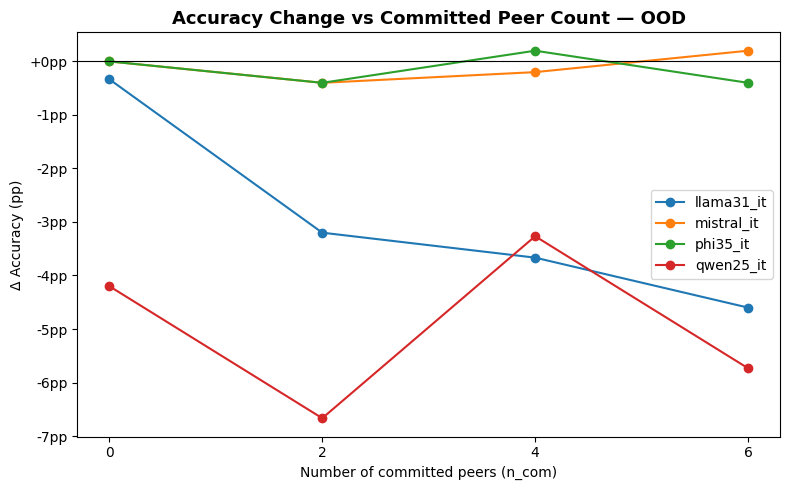

In [7]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    for model in MODELS:
        df_m = combined_ood[(combined_ood["model"] == model) & (combined_ood["condition"].isin([f"rq2a_commit{n}" for n in N_COM]))].copy()
        df_m["n_com"] = df_m["condition"].str.extract(r"commit(\d+)").astype(int)
        df_m = df_m.sort_values("n_com")
        ax.plot(df_m["n_com"], df_m["delta_acc"], marker="o", label=model)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Number of committed peers (n_com)")
    ax.set_ylabel("Δ Accuracy (pp)")
    ax.set_title("Accuracy Change vs Committed Peer Count — OOD", fontsize=13, fontweight="bold")
    ax.set_xticks(N_COM)
    ax.legend()
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "rq2a_ood_delta_acc_vs_ncom.png", dpi=150, bbox_inches="tight")
    plt.show()


## Harmful % vs n_com — OOD

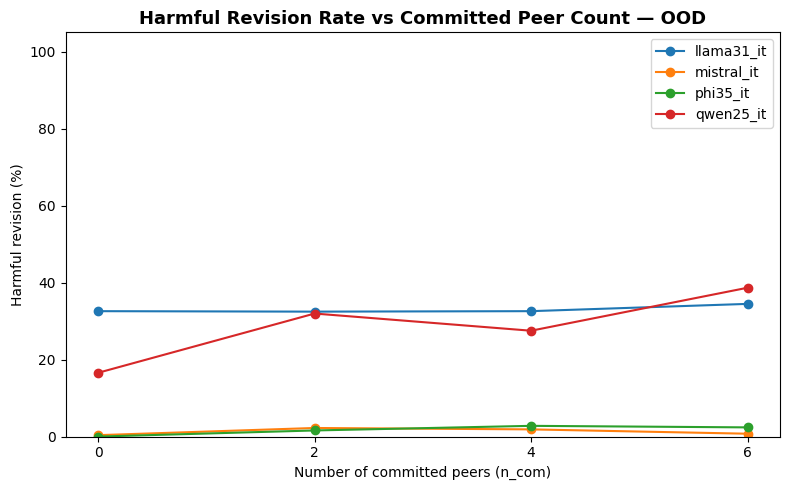

In [8]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    for model in MODELS:
        df_m = combined_ood[(combined_ood["model"] == model) & (combined_ood["condition"].isin([f"rq2a_commit{n}" for n in N_COM]))].copy()
        df_m["n_com"] = df_m["condition"].str.extract(r"commit(\d+)").astype(int)
        df_m = df_m.sort_values("n_com")
        ax.plot(df_m["n_com"], df_m["harm_pct"], marker="o", label=model)

    ax.set_xlabel("Number of committed peers (n_com)")
    ax.set_ylabel("Harmful revision (%)")
    ax.set_title("Harmful Revision Rate vs Committed Peer Count — OOD", fontsize=13, fontweight="bold")
    ax.set_xticks(N_COM)
    ax.set_ylim(0, 105)
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "rq2a_ood_harmful_vs_ncom.png", dpi=150, bbox_inches="tight")
    plt.show()


## Δ Accuracy heatmap — models × conditions — OOD

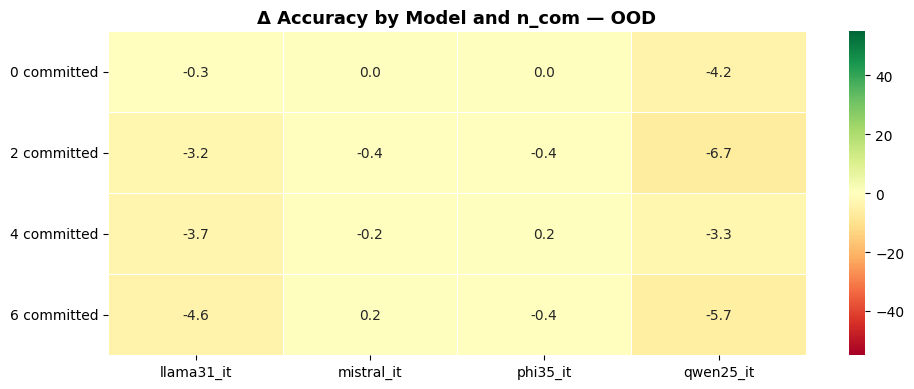

In [9]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    df_plot = combined_ood[combined_ood["condition"].isin([f"rq2a_commit{n}" for n in N_COM])]
    pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
    pivot = pivot.reindex([f"rq2a_commit{n}" for n in N_COM if f"rq2a_commit{n}" in pivot.index])
    fig, ax = plt.subplots(figsize=(max(6, 2.5*len(MODELS)), 4))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
                linewidths=0.5, ax=ax, annot_kws={"size": 10})
    ax.set_title("Δ Accuracy by Model and n_com — OOD", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels([CONDITION_LABELS.get(c, c) for c in pivot.index], rotation=0)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "rq2a_ood_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


## ID vs OOD: Δ Accuracy vs n_com

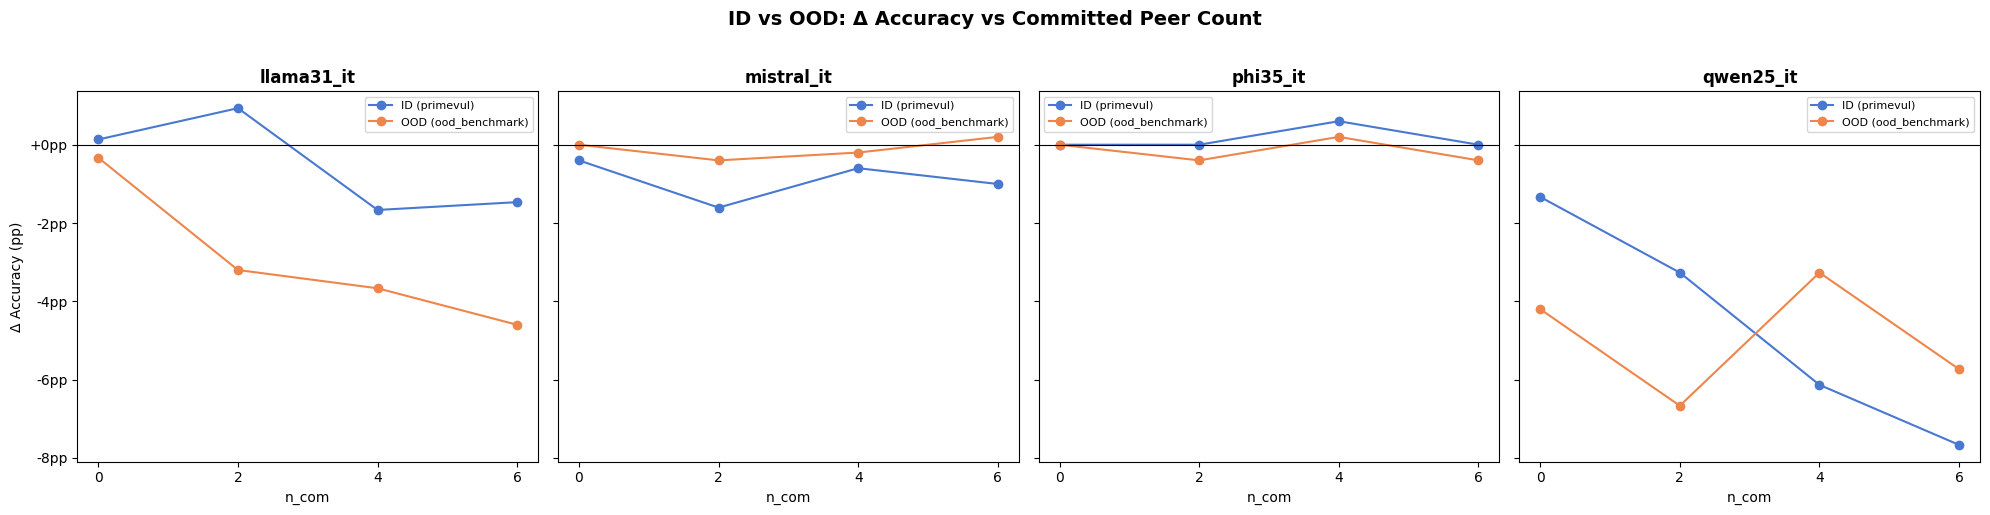

In [10]:
if combined_ood.empty:
    print("No OOD data found.")
else:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 5), sharey=True)
    if len(MODELS) == 1:
        axes = [axes]

    for ax, model in zip(axes, MODELS):
        for df, label, color in [(combined, "ID (primevul)", "#4878d0"), (combined_ood, "OOD (ood_benchmark)", "#ee854a")]:
            df_m = df[(df["model"] == model) & (df["condition"].isin([f"rq2a_commit{n}" for n in N_COM]))].copy()
            df_m["n_com"] = df_m["condition"].str.extract(r"commit(\d+)").astype(int)
            df_m = df_m.sort_values("n_com")
            ax.plot(df_m["n_com"], df_m["delta_acc"], marker="o", color=color, label=label)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_xlabel("n_com")
        ax.set_ylabel("Δ Accuracy (pp)" if ax == axes[0] else "")
        ax.set_xticks(N_COM)
        ax.legend(fontsize=8)
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))

    plt.suptitle("ID vs OOD: Δ Accuracy vs Committed Peer Count", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "rq2a_id_vs_ood_delta_acc.png", dpi=150, bbox_inches="tight")
    plt.show()
